# Reading Data

In [62]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [63]:
df = pd.read_csv('./pokemon.csv')
df

,Name,Type1,Type2,Evolution
0,bulbasaur,Grass,Poison,ivysaur
1,ivysaur,Grass,Poison,venusaur
2,venusaur,Grass,Poison,NaN
3,charmander,Fire,NaN,charmeleon
4,charmeleon,Fire,NaN,charizard
...,...,...,...,...
804,stakataka,Rock,Steel,NaN
805,blacephalon,Fire,Ghost,NaN
806,zeraora,Electric,NaN,NaN
807,meltan,Steel,NaN,NaN


In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 809 entries, 0 to 808
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Name       809 non-null    str  
 1   Type1      809 non-null    str  
 2   Type2      405 non-null    str  
 3   Evolution  32 non-null     str  
dtypes: str(4)
memory usage: 25.4 KB


In [65]:
df.describe()

,Name,Type1,Type2,Evolution
count,809,809,405,32
unique,809,18,18,32
top,bulbasaur,Water,Flying,ivysaur
freq,1,114,95,1


In [66]:
df['Type1'].unique()

<StringArray>
[   'Grass',     'Fire',    'Water',      'Bug',   'Normal',   'Poison',
 'Electric',   'Ground',    'Fairy', 'Fighting',  'Psychic',     'Rock',
    'Ghost',      'Ice',   'Dragon',     'Dark',    'Steel',   'Flying']
Length: 18, dtype: str

# EDA

/tmp/ipykernel_1383824/765583017.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Type1', palette='icefire');


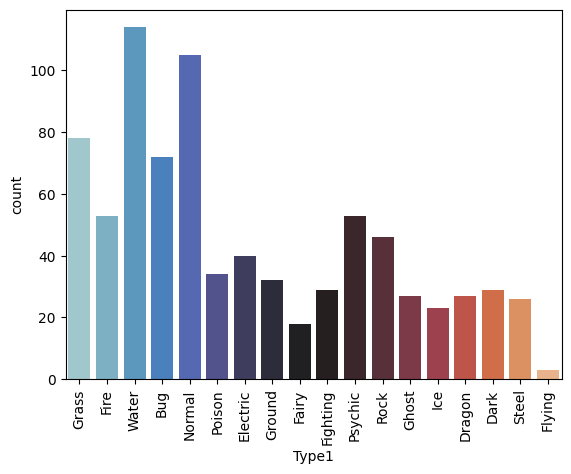

In [67]:
sns.countplot(data=df, x='Type1', palette='icefire');
plt.xticks(rotation=90);

/tmp/ipykernel_1383824/3598261116.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Type2', palette='icefire');


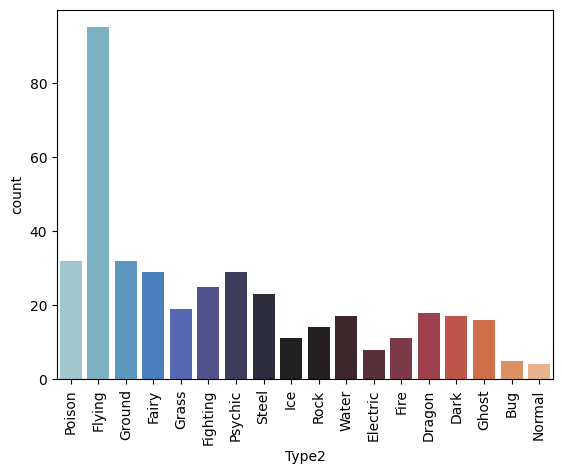

In [68]:
sns.countplot(data=df, x='Type2', palette='icefire');
plt.xticks(rotation=90);

In [69]:
new_df = pd.crosstab(df['Type1'], df['Type2'])
new_df.head()

Type2,Bug,Dark,Dragon,Electric,Fairy,Fighting,Fire,Flying,Ghost,Grass,Ground,Ice,Normal,Poison,Psychic,Rock,Steel,Water
Type1,,,,,,,,,,,,,,,,,,
Bug,0,0,0,4,2,3,2,13,1,6,1,0,0,11,0,3,5,3
Dark,0,0,4,0,0,2,2,5,1,0,0,2,0,0,2,0,2,0
Dragon,0,0,0,1,0,2,1,4,0,0,4,1,0,0,2,0,0,0
Electric,0,0,0,0,2,0,0,3,1,0,0,0,2,0,0,0,4,0
Fairy,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0


<Axes: xlabel='Type2', ylabel='Type2'>

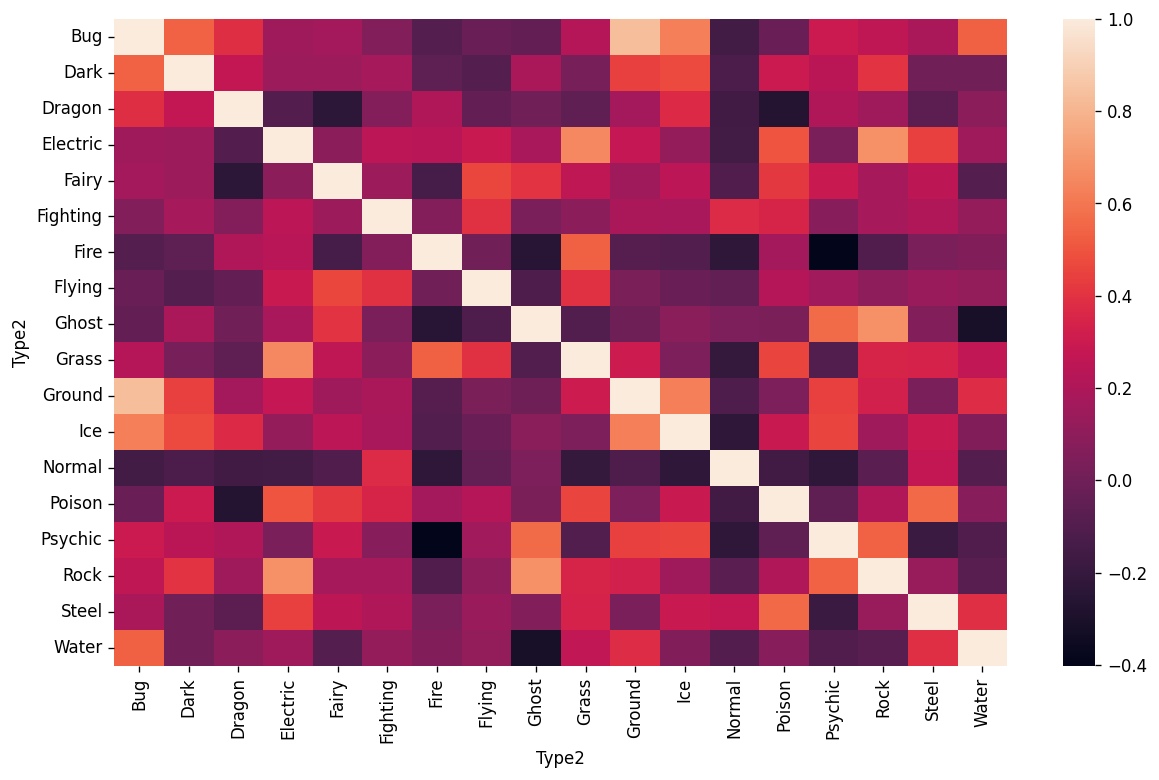

In [70]:
plt.figure(figsize=(12,7), dpi=120)
sns.heatmap(new_df.corr())

In [71]:
fire_df = df[df['Type1'] == 'Fire']

In [72]:
fire_df.head()

,Name,Type1,Type2,Evolution
3,charmander,Fire,NaN,charmeleon
4,charmeleon,Fire,NaN,charizard
5,charizard,Fire,Flying,NaN
36,vulpix,Fire,NaN,ninetales
37,ninetales,Fire,NaN,NaN


In [73]:
fire_sample = fire_df.sample(n=25, random_state=101)
fire_names = fire_df['Name'].tolist()
fire_names

['charmander',
 'charmeleon',
 'charizard',
 'vulpix',
 'ninetales',
 'growlithe',
 'arcanine',
 'ponyta',
 'rapidash',
 'magmar',
 'flareon',
 'moltres',
 'cyndaquil',
 'quilava',
 'typhlosion',
 'slugma',
 'magcargo',
 'magby',
 'entei',
 'ho-oh',
 'torchic',
 'combusken',
 'blaziken',
 'numel',
 'camerupt',
 'torkoal',
 'chimchar',
 'monferno',
 'infernape',
 'magmortar',
 'heatran',
 'tepig',
 'pignite',
 'emboar',
 'pansear',
 'simisear',
 'darumaka',
 'darmanitan-standard',
 'heatmor',
 'fennekin',
 'braixen',
 'delphox',
 'fletchinder',
 'talonflame',
 'litleo',
 'pyroar',
 'volcanion',
 'litten',
 'torracat',
 'incineroar',
 'oricorio-baile',
 'turtonator',
 'blacephalon']

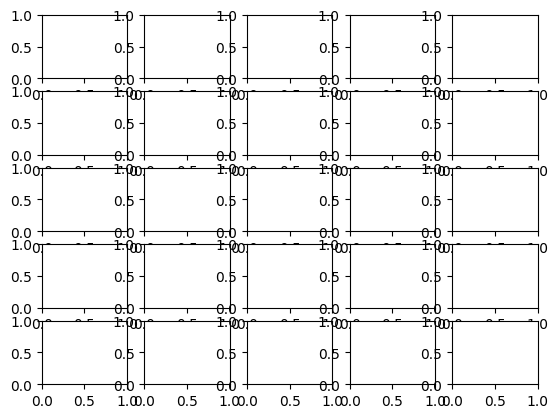

In [74]:
# plt.figure(figsize=(12,7), dpi=120)
fig, ax = plt.subplots(5,5)
# ax.plot()

<Figure size 1440x840 with 0 Axes>

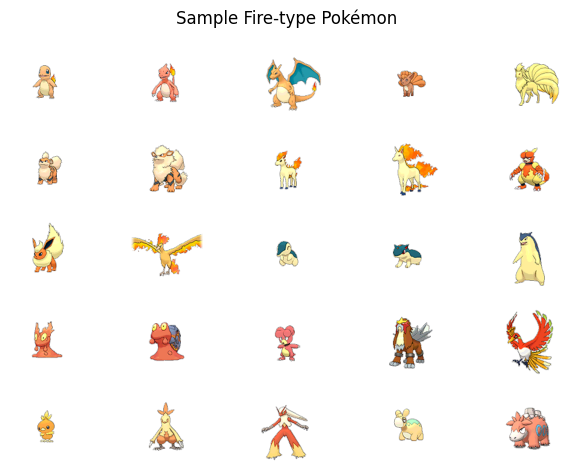

In [75]:
from PIL import Image

plt.figure(figsize=(12,7), dpi=120)
fig, ax = plt.subplots(5,5)

rows = 0
cols = 0

for idx, names in enumerate(fire_names):
    
    rows = idx // 5
    cols = idx % 5
    
    # img = Image.open('./images-and-data/' + names + '.png')
    
    # ax[rows][cols].imshow(img)
    # ax[rows][cols].axis('off')
    
    try:
        img = Image.open('./images-and-data/' + names + '.png')
        ax[rows][cols].imshow(img)
        ax[rows][cols].axis('off')
    except IndexError:
        pass
    
    # ax[rows][cols].set_title(fire_names, fontsize=8)

fig.suptitle('Sample Fire-type Pokémon')
plt.tight_layout()
plt.show()

In [76]:
import os

In [77]:
path = './images-and-data'
content = os.listdir(path)

justnames = []

for i in content:
    morenames = i.replace('.png', '')
    justnames.append(morenames)

In [78]:
len(justnames)

809

# Feature Extraction

In [79]:
img_array = []

path = './images-and-data'
img_path = os.listdir(path)

for i in img_path:
    a = Image.open(path + '/' + i)
    b = np.array(a)
    rbg_array = b[:,:,:3] # make it not transprant
    
    img_array.append(rbg_array)

In [80]:
img_array[0].shape

(120, 120, 3)

Text(0.5, 1.0, 'charmander')

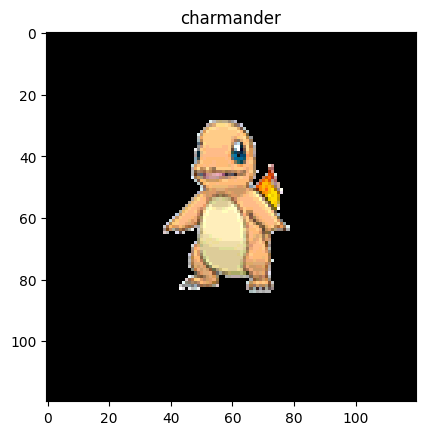

In [81]:
n = 95
pokemon_img = img_array[n]
pokemon_name = img_path[n].replace('.png', '')

plt.imshow(pokemon_img)
plt.title(pokemon_name)

In [82]:
# Making Histplot

red_array = []
red_hist_arr = []

for i in range(809):
    red = img_array[i]
    red_array.append(red[:,:,0])
    
for i in range(809):
    red_flat = red_array[i].ravel()
    counts, bin_edges = np.histogram(red_flat, bins=16, range=(0,256))
    red_hist_arr.append(counts)

In [83]:
green_array = []
green_hist_arr = []

for i in range(809):
    green = img_array[i]
    green_array.append(green[:,:,1])
    
for i in range(809):
    green_flat = green_array[i].ravel()
    counts, bin_edges = np.histogram(green_flat, bins=16, range=(0,256))
    green_hist_arr.append(counts)

In [84]:
blue_array = []
blue_hist_arr = []

for i in range(809):
    blue = img_array[i]
    blue_array.append(blue[:,:,2])
    
for i in range(809):
    blue_flat = blue_array[i].ravel()
    counts, bin_edges = np.histogram(blue_flat, bins=16, range=(0,256))
    blue_hist_arr.append(counts)

In [85]:
# Combaining RGB in 1 array

rgb_hist = []

for i in range(809):
    pre_rgb_hist = np.concatenate((red_hist_arr[i] , green_hist_arr[i] , blue_hist_arr[i]))
    
    rgb_hist.append(pre_rgb_hist)

In [86]:
rgb_hist[0]

array([8982,   12,   41,  113,  138,  306,  445,  560,  152,  158,  164,
        247,  225,  212,  523, 2122, 8979,    1,    7,   11,   42,   99,
        114,  274,  313,  302,  744,  312,  303,  222,  215, 2462, 8979,
          1,    5,   15,   51,  104,  132,  264,  326,  715,  394,  181,
        260,  217,  202, 2554])

In [87]:
# Converting rgb_hist in proper array

rgb_hist = np.asarray(rgb_hist)

In [88]:
rgb_hist.shape

(809, 48)

In [89]:
type_name = []

path = './images-and-data'
content = os.listdir(path)

for i in content:
    just_names = i.replace('.png', '')
    type_name.append(just_names)

In [90]:
type_value = []

for name in type_name:
    match = df[df['Name'] == name]
    type1_value = match['Type1'].iloc[0]
    type_value.append(type1_value)

In [91]:
len(type_value)

809

In [92]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [93]:
type_value_encoded = le.fit_transform(type_value)

In [94]:
from sklearn.model_selection import train_test_split

In [95]:
X = rgb_hist
y = type_value_encoded

In [96]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

In [97]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [98]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [99]:
from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import GridSearchCV

In [100]:
# n_estimator = [64,100,128,200]
# max_features = [2,3,4]
# bootstrap = [True, False]
# obb_score = [True, False]

In [101]:
# param_grid = {'n_estimator': n_estimator,
#               'max_features': max_features,
#               'bootstrap': bootstrap,
#               'obb_score': obb_score}

In [102]:
rfc = RandomForestClassifier(n_estimators=20)

In [103]:
rfc.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [104]:
predictions = rfc.predict(X_test_scaled)

In [105]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error

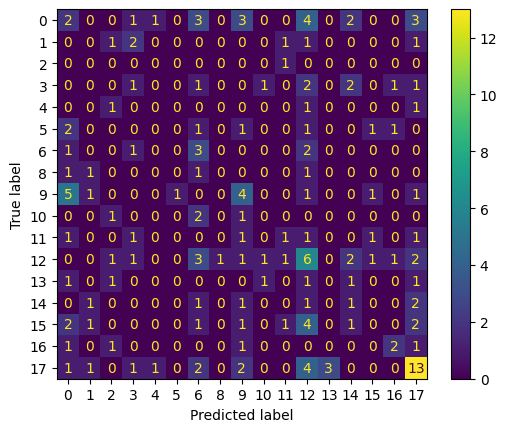

In [106]:
ConfusionMatrixDisplay.from_estimator(rfc, X_test_scaled, y_test)

In [107]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.12      0.11      0.11        19
           1       0.00      0.00      0.00         6
           2       0.00      0.00      0.00         1
           3       0.12      0.11      0.12         9
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         7
           6       0.17      0.43      0.24         7
           8       0.00      0.00      0.00         4
           9       0.25      0.29      0.27        14
          10       0.00      0.00      0.00         4
          11       0.20      0.14      0.17         7
          12       0.20      0.29      0.24        21
          13       0.00      0.00      0.00         6
          14       0.11      0.14      0.12         7
          15       0.00      0.00      0.00        13
          16       0.40      0.33      0.36         6
          17       0.45      0.46      0.46        28

    accuracy              

In [108]:
accuracy_score(y_test, predictions)

0.2037037037037037

In [109]:
mae = mean_absolute_error(y_test, predictions)
mae

5.685185185185185

In [110]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
rmse

np.float64(7.501028736031174)

In [111]:
le.classes_[1]

np.str_('Dark')

In [112]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [113]:
def run_models(model, X_train, y_train, X_test, y_test):
    
    #model fit
    model.fit(X_train, y_train)
    
    #model predict
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f'MAE:{mae}')
    print(f'RMSE:{rmse}')
    
    acc_score = accuracy_score(y_test, preds)
    print(f'Accuracy Score: {acc_score}')
    
    class_report = print(classification_report(y_test, preds))
    print(f'Classification Report: {class_report}')

In [114]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [115]:
log_model = LogisticRegression()
dtc = DecisionTreeClassifier(random_state=51, criterion='gini', max_depth=3)
knn_model = KNeighborsClassifier()
rfc_model = RandomForestClassifier(n_estimators=80)

In [116]:
run_models(log_model, X_train_scaled, y_train, X_test_scaled, y_test)

MAE:5.277777777777778
RMSE:7.16946543111139
Accuracy Score: 0.24691358024691357
              precision    recall  f1-score   support

           0       0.25      0.16      0.19        19
           1       0.33      0.33      0.33         6
           2       0.00      0.00      0.00         1
           3       0.20      0.11      0.14         9
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         7
           6       0.17      0.29      0.21         7
           8       0.00      0.00      0.00         4
           9       0.38      0.43      0.40        14
          10       0.00      0.00      0.00         4
          11       0.12      0.14      0.13         7
          12       0.23      0.33      0.27        21
          13       0.33      0.33      0.33         6
          14       0.11      0.14      0.12         7
          15       0.00      0.00      0.00        13
          16       0.33      0.17      0.22         6
 

/home/shadow/.pyenv/versions/3.11.15/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/shadow/.pyenv/versions/3.11.15/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/shadow/.pyenv/versions/3.11.15/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

In [117]:
run_models(dtc, X_train_scaled, y_train, X_test_scaled, y_test)
# ConfusionMatrixDisplay.from_estimator(dtc, X_test_scaled, y_test)
# le.classes_[12]

MAE:6.117283950617284
RMSE:7.951628453450802
Accuracy Score: 0.18518518518518517
              precision    recall  f1-score   support

           0       0.14      0.37      0.20        19
           1       0.00      0.00      0.00         6
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         9
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         7
           6       0.00      0.00      0.00         7
           8       0.00      0.00      0.00         4
           9       0.14      0.36      0.20        14
          10       0.00      0.00      0.00         4
          11       0.00      0.00      0.00         7
          12       0.21      0.29      0.24        21
          13       0.00      0.00      0.00         6
          14       0.00      0.00      0.00         7
          15       0.00      0.00      0.00        13
          16       0.00      0.00      0.00         6


/home/shadow/.pyenv/versions/3.11.15/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/shadow/.pyenv/versions/3.11.15/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/shadow/.pyenv/versions/3.11.15/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

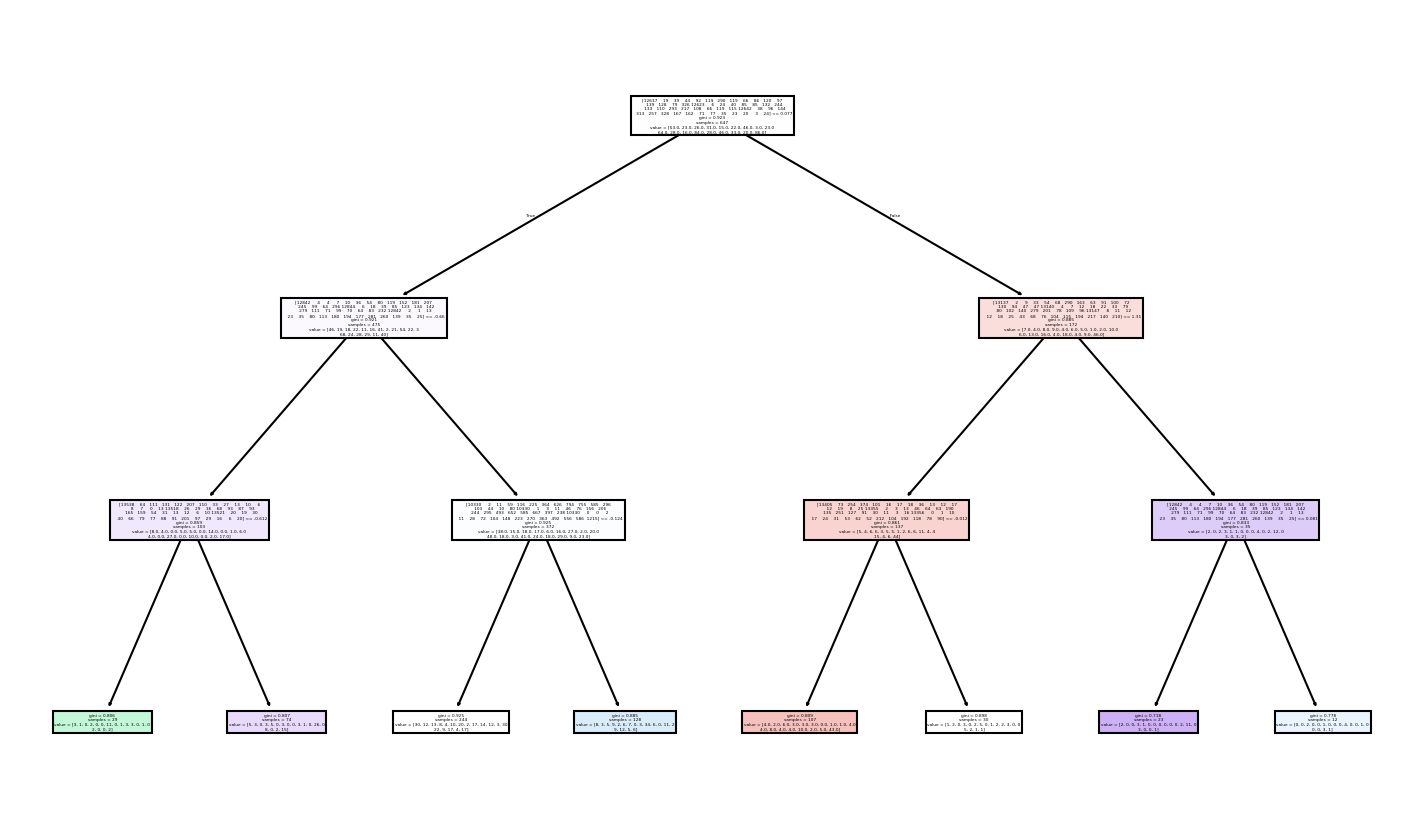

In [118]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12,7), dpi=150)
plot_tree(dtc, feature_names=X, filled=True);

In [119]:
run_models(knn_model, X_train_scaled, y_train, X_test_scaled, y_test)
# ConfusionMatrixDisplay.from_estimator(knn_model, X_test_scaled, y_test)
# le.classes_[9]

MAE:6.265432098765432
RMSE:8.107685730295334
Accuracy Score: 0.16666666666666666
              precision    recall  f1-score   support

           0       0.17      0.47      0.25        19
           1       0.11      0.17      0.13         6
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         9
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         7
           6       0.18      0.29      0.22         7
           7       0.00      0.00      0.00         0
           8       0.00      0.00      0.00         4
           9       0.36      0.29      0.32        14
          10       0.00      0.00      0.00         4
          11       0.00      0.00      0.00         7
          12       0.13      0.10      0.11        21
          13       0.20      0.17      0.18         6
          14       0.00      0.00      0.00         7
          15       0.00      0.00      0.00        13


/home/shadow/.pyenv/versions/3.11.15/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/shadow/.pyenv/versions/3.11.15/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/shadow/.pyenv/versions/3.11.15/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

In [120]:
run_models(rfc_model, X_train_scaled, y_train, X_test_scaled, y_test)

MAE:4.716049382716049
RMSE:6.620208493229436
Accuracy Score: 0.2839506172839506
              precision    recall  f1-score   support

           0       0.36      0.21      0.27        19
           1       0.20      0.17      0.18         6
           2       0.00      0.00      0.00         1
           3       0.50      0.11      0.18         9
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         7
           6       0.14      0.29      0.19         7
           8       0.00      0.00      0.00         4
           9       0.27      0.43      0.33        14
          10       0.00      0.00      0.00         4
          11       0.00      0.00      0.00         7
          12       0.22      0.33      0.26        21
          13       0.29      0.33      0.31         6
          14       0.25      0.14      0.18         7
          15       0.00      0.00      0.00        13
          16       0.40      0.33      0.36         6
 

/home/shadow/.pyenv/versions/3.11.15/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/shadow/.pyenv/versions/3.11.15/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/shadow/.pyenv/versions/3.11.15/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

In [121]:
import pickle

In [122]:
pickle.dump(rfc,open('rfc_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(le, open('label_encoder.pkl', 'wb'))